In [119]:
from pathlib import Path

import numpy as np
import pandas as pd
import re
from sklearn.base import BaseEstimator, TransformerMixin
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [120]:
def find_project_root(start: Path | None = None) -> Path:
    """Walk upward until pyproject.toml is found."""
    current = (start or Path.cwd()).resolve()

    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find project root containing pyproject.toml"
    )


ROOT = find_project_root()
IBM_TRAINING = ROOT / "share_IBM_training"
OPTICAL_DATA = ROOT / "Optical_Axis_Alignment_Data"

DATA_DIR = ROOT / "processed"

DATA_DIR

WindowsPath('C:/Users/BS01493/Projects/SBU Europe/Client/GigaAI/Client Data - v3/data/processed')

In [121]:
# 1 -> OK, 0 -> NG
RANK_MAP = {
    "S": 1,
    "A": 1,
    "B": 1,
    "C": 0,
    "D": 0,
    "E": 0,
}

AMP_SUMMARY_KEEP = [
    "AMP HV","OSC HV","Energy","OSC Energy",
    "BD Size Hor","BD Size Ver","BD COG Hor","BD COG Ver",
    "BP Size Hor","BP Size Ver","BP ContM Hor","BP ContM Ver",
    "Energy Sigma","Dose Max","Dose min","Dose R","Dose U",
    "Wavelength Ave Max","Wavelength Ave min","Wavelength Sigma Max",
    "AFM H Adjustment Amount","AFM V Adjustment Amount",
    "AFM x centroid","AFM y centroid",
]

OSC_SUMMARY_KEEP = [
    "AMP HV","OSC HV","Energy","OSC Energy",
    "BD Size Hor","BD Size Ver","BD COG Hor","BD COG Ver",
    "BP Size Hor","BP Size Ver","BP ContM Hor","BP ContM Ver",
    "Energy Sigma","Dose Max","Dose min","Dose R","Dose U",
    "Wavelength Ave Max","Wavelength Ave min","Wavelength Sigma Max",
    "OBS Upper H Adjustment Amount","OBS Upper V Adjustment Amount",
    "OBS Lower H Adjustment Amount","OBS Lower V Adjustment Amount",
    "OBS Upper x centroid","OBS Upper y centroid",
]

In [122]:
def build_dataset(
    beam_path,
    summary_path,
    keep_cols,
):
    beam = pd.read_csv(beam_path)
    summary = pd.read_csv(summary_path)

    assert len(beam) == len(summary)

    summary_feats = summary[[c for c in keep_cols if c in summary.columns]].copy()

    for col in summary_feats.columns:
        summary_feats[col] = summary_feats[col].fillna(
            summary_feats[col].median()
        )

    return pd.concat(
        [
            summary[["Laser", "No"]],
            summary["Rank"].map(RANK_MAP).astype(np.int8).rename("rank_int"),
            beam,
            summary_feats,
        ],
        axis=1,
    )

In [123]:
amp = build_dataset(
    DATA_DIR / "beam_physical_feature_amp.csv",
    IBM_TRAINING / "AMP_summary.csv",
    AMP_SUMMARY_KEEP,
)

amp.shape

(271, 204)

In [124]:
amp["rank_int"].value_counts().sort_index()

rank_int
0    162
1    109
Name: count, dtype: int64

In [125]:
osc = build_dataset(
    DATA_DIR / "beam_physical_feature_osc.csv",
    IBM_TRAINING / "OSC_summary.csv",
    OSC_SUMMARY_KEEP,
)

osc.shape

(307, 206)

In [126]:
osc["rank_int"].value_counts().sort_index()

rank_int
0    208
1     99
Name: count, dtype: int64

In [127]:
for name, df in {
    "AMP": amp,
    "OSC": osc,
}.items():

    assert "Laser" in df.columns
    assert "No" in df.columns
    assert "rank_int" in df.columns
    assert df["rank_int"].notna().all()

    print(
        f"{name}: {df.shape[0]} rows × {df.shape[1]} cols ✓"
    )

AMP: 271 rows × 204 cols ✓
OSC: 307 rows × 206 cols ✓


In [128]:
class VarianceCorrelationFilter(BaseEstimator, TransformerMixin):
    """
    A generic scikit-learn transformer to filter out low-variance features 
    and highly correlated feature pairs from a pandas DataFrame, optimized for high-dimensional data.
    """
    def __init__(self, var_threshold=1e-6, corr_threshold=0.97):
        self.var_threshold = var_threshold
        self.corr_threshold = corr_threshold
        self.kept_cols_ = []
        
        # Internal state saved for visualization purposes
        self.high_var_cols_ = []
        self.corr_matrix_ = None
        self.drop_cols_ = []

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
            
        # -------------------------
        # Stage 1: Variance Filter
        # -------------------------
        variances = X.var(numeric_only=True)
        self.high_var_cols_ = [c for c in X.columns if variances.get(c, 0) >= self.var_threshold]
        
        if not self.high_var_cols_:
            self.kept_cols_ = []
            return self

        # -------------------------
        # Stage 2: Correlation Filter
        # -------------------------
        self.corr_matrix_ = X[self.high_var_cols_].corr().abs()
        
        upper_tri = self.corr_matrix_.where(np.triu(np.ones(self.corr_matrix_.shape), k=1).astype(bool))
        self.drop_cols_ = [column for column in upper_tri.columns if any(upper_tri[column] > self.corr_threshold)]
        
        self.kept_cols_ = [c for c in self.high_var_cols_ if c not in self.drop_cols_]
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        return X[self.kept_cols_]

    def visualize_correlations(self, top_n=20):
        """
        Extracts and displays a clean list of the top N highest correlated feature pairs.
        """
        if self.corr_matrix_ is None:
            raise ValueError("The transformer must be fitted (`.fit()`) before visualizing.")
            
        # Get the upper triangle mask to avoid duplicate pairs (A-B and B-A) and self-correlation (A-A)
        upper_tri = np.triu(np.ones_like(self.corr_matrix_, dtype=bool), k=1)
        
        # Flatten the matrix into a tidy Series of pairs
        corr_pairs = self.corr_matrix_.where(upper_tri).stack()
        
        # Convert to a DataFrame and sort by absolute correlation descending
        corr_df = corr_pairs.reset_index()
        corr_df.columns = ['Feature 1', 'Feature 2', 'Correlation']
        corr_df = corr_df.sort_values(by='Correlation', ascending=False).reset_index(drop=True)
        
        # Add tracking to show which columns are being dropped by the filter
        corr_df['Action'] = corr_df.apply(
            lambda row: f"Drop {row['Feature 2']}" if row['Feature 2'] in self.drop_cols_ 
            else (f"Drop {row['Feature 1']}" if row['Feature 1'] in self.drop_cols_ else "Keep Both"),
            axis=1
        )
        
        # Get the top N rows
        top_corrs = corr_df.head(top_n)
        
        # Display results cleanly using pandas styling
        print(f"\n=== TOP {top_n} HIGHEST CORRELATIONS ===")
        print(f"Current Filter Threshold: {self.corr_threshold}\n")
        
        # Beautiful console or Jupyter notebook formatting
        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', 1000)
        print(top_corrs.to_string(index=True, formatters={'Correlation': '{:,.4f}'.format}))
        
        return top_corrs

In [129]:
from sklearn.preprocessing import LabelEncoder

def preprocess_dataframe(df, target_col='rank_int', index_col='No', encode_col='Laser', return_encoder=False):
    """
    Preprocesses the dataframe by dropping specific columns, setting an index,
    and label-encoding a categorical column. Separates features from target.
    
    Parameters:
    -----------
    df : pd.DataFrame
        The raw input DataFrame.
    target_col : str
        The output/target column name to extract as 'y'.
    index_col : str
        The column name to be used as the DataFrame index.
    encode_col : str
        The categorical column name to label-encode.
    return_encoder : bool
        If True, returns the fitted LabelEncoder object along with X and y.
        
    Returns:
    --------
    X : pd.DataFrame
        The processed features.
    y : pd.Series
        The target variable.
    le : LabelEncoder (Optional)
        The fitted encoder for the categorical column.
    """
    # Create a copy to prevent modifying the original DataFrame out of place
    processed_df = df.copy()
    
    # 1. Drop the specified columns
    cols_to_drop = ['session_id', 'label', 'BP_extraction_ok', 'BD_extraction_ok']
    processed_df = processed_df.drop(columns=cols_to_drop, errors='ignore')
    
    # 2. Index the dataframe
    if index_col in processed_df.columns:
        processed_df = processed_df.set_index(index_col)
    else:
        raise KeyError(f"The index column '{index_col}' was not found in the DataFrame.")
        
    # 3. Label-encode the specified column
    le = None
    if encode_col in processed_df.columns:
        le = LabelEncoder()
        processed_df[encode_col] = le.fit_transform(processed_df[encode_col].astype(str))
    else:
        print(f"Warning: Column '{encode_col}' not found for label encoding. Skipping.")
        
    # 4. Separate features (X) and target (y)
    if target_col in processed_df.columns:
        y = processed_df[target_col]
        X = processed_df.drop(columns=[target_col])
    else:
        raise KeyError(f"The target column '{target_col}' was not found in the DataFrame.")
        
    if return_encoder:
        return X, y, le
    return X, y

In [130]:
# 5-Fold Stratified CV for stable evaluation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Simple hyperparameter spaces to explore for best-fold tuning
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced', 'balanced_subsample']
    
}

lgbm_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [5, 10, -1],
    'is_unbalance': [True, False]
}

xgb_param_grid = {
    # 1. Structural Controls (Prevents Overfitting)
    'max_depth': [4, 6, 8],                # Shalled depths prevent overfitting on high dimensions
    'min_child_weight': [1, 5, 10],         # Higher values prevent modeling noise in small clusters
    
    # 2. Stochastic/Sampling Features (Forces tree diversity)
    'subsample': [0.7, 0.9],               # Fraction of rows sampled per tree
    'colsample_bytree': [0.6, 0.8],        # Fraction of columns sampled per tree (great for ~200 cols)
    
    # 3. Learning Rate & Trees
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    
    # 4. Regularization
    'reg_alpha': [0, 1, 5],                # L1 regularization (acts like a feature selector)
    'reg_lambda': [1, 5]                   # L2 regularization
}

In [131]:
def evaluate_cross_validation(model_name, grid_search, X_train, y_train):
    """ Extracts and prints metrics for every individual fold from GridSearchCV """
    print(f"\n==================================================")
    print(f"      CROSS-VALIDATION RESULTS: {model_name}       ")
    print(f"==================================================")
    
    # FIX: Safely retrieve n_splits from the grid search cv attribute
    # If cv is an integer, use it; if it's a cross-validation object, get its n_splits
    cv_obj = grid_search.cv
    n_splits = cv_obj.n_splits if hasattr(cv_obj, 'n_splits') else cv_obj
    
    # StratifiedKFold splits indices identically to how GridSearchCV runs them internally
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # We evaluate using the optimal parameter set identified by the grid search
    best_model = grid_search.best_estimator_
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        # Recreate the exact fold split
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        # Fit model specifically on this fold using best params
        fold_model = best_model.fit(X_tr, y_tr)
        preds = fold_model.predict(X_val)
        
        # Calculate explicit metrics for the binary classification
        acc = accuracy_score(y_val, preds)
        prec = precision_score(y_val, preds, zero_division=0)
        rec = recall_score(y_val, preds, zero_division=0)
        f1 = f1_score(y_val, preds, zero_division=0)
        
        print(f"Fold {fold + 1} -> Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
        
    print(f"\n---> Best Model Parameters:")
    for param, value in grid_search.best_params_.items():
        print(f"     * {param}: {value}")

In [132]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    """
    Plots a beautifully formatted confusion matrix showing both 
    raw counts and normalized percentages for binary classification.
    """
    # Compute the standard confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Compute normalized percentages (divide by total samples)
    cm_percent = cm.astype('float') / cm.sum() * 100
    
    # Create text labels combining: [Count] \n [Percentage%]
    labels = [
        f"{count}\n({pct:.2f}%)" 
        for count, pct in zip(cm.flatten(), cm_percent.flatten())
    ]
    labels = np.asarray(labels).reshape(2, 2)
    
    # Set up the plot layout
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, 
        annot=labels, 
        fmt="",       # Necessary to allow custom string labels instead of default formatting
        cmap="Blues", 
        cbar=False,   # Hide colorbar for a cleaner, self-contained look
        xticklabels=['Predicted 0', 'Predicted 1'],
        yticklabels=['Actual 0', 'Actual 1'],
        annot_kws={"size": 12, "weight": "bold"}
    )
    
    plt.title(f"Confusion Matrix - {model_name}\n(Counts & Percentages)", fontsize=13, pad=15, fontweight='bold')
    plt.ylabel('True Labels', fontsize=11)
    plt.xlabel('Predicted Labels', fontsize=11)
    plt.tight_layout()
    plt.show()

# AMP

In [133]:
for col, dtype in amp.dtypes.items():
    print(f"{col}: {dtype}")

Laser: str
No: int64
rank_int: int8
session_id: int64
label: str
BP_extraction_ok: bool
BD_extraction_ok: bool
BP_global_mean: float64
BP_global_std: float64
BP_global_max: float64
BP_global_p10: float64
BP_global_p90: float64
BP_global_p99: float64
BP_peak_to_mean: float64
BP_p90_to_mean: float64
BP_frac_above_p90: float64
BP_frac_above_p95: float64
BP_iso_centroid_x: float64
BP_iso_centroid_y: float64
BP_iso_d_major: float64
BP_iso_d_minor: float64
BP_iso_ellipticity: float64
BP_iso_rotation_deg: float64
BP_iso_eccentricity: float64
BP_gauss_amplitude: float64
BP_gauss_sigma_x: float64
BP_gauss_sigma_y: float64
BP_gauss_residual_rmse: float64
BP_gauss_residual_max: float64
BP_gauss_fit_ok: bool
BP_iso_flatness_factor: float64
BP_iso_beam_uniformity: float64
BP_iso_plateau_uniformity: float64
BP_iso_edge_steepness: float64
BP_iso_fractional_power: float64
BP_iso_clip_area: float64
BP_iso_beam_aspect_ratio: float64
BP_iso_top_hat_factor: float64
BP_sym_horizontal: float64
BP_sym_vertic

In [134]:
print(amp["label"].value_counts())
print(amp["BP_extraction_ok"].value_counts())
print(amp["BD_extraction_ok"].value_counts())
print(amp["session_id"].value_counts())

label
AMP    271
Name: count, dtype: int64
BP_extraction_ok
True    271
Name: count, dtype: int64
BD_extraction_ok
True    271
Name: count, dtype: int64
session_id
0      1
100    1
101    1
102    1
103    1
      ..
96     1
97     1
98     1
99     1
9      1
Name: count, Length: 271, dtype: int64


In [135]:
# 1. Run the preprocessing function
output = preprocess_dataframe(amp)
X_amp = output[0]
y_amp = output[1]
laser_encoder_amp = output[2] if len(output) > 2 else None

In [136]:
print(X_amp.shape)

(271, 198)


In [137]:
# 2. Fit and transform using your generic filter
feature_filter = VarianceCorrelationFilter(var_threshold=1e-6, corr_threshold=0.95)
X_filtered_amp = feature_filter.fit_transform(X_amp)

# 3. Visualise the correlations if desired
feature_filter.visualize_correlations()
X_filtered_amp.shape


=== TOP 20 HIGHEST CORRELATIONS ===
Current Filter Threshold: 0.95

              Feature 1             Feature 2 Correlation                     Action
0       BP_sym_vertical         BP_sym_diag_2      1.0000         Drop BP_sym_diag_2
1       BD_sym_vertical         BD_sym_diag_2      1.0000         Drop BD_sym_diag_2
2    BP_marginal_skew_y  BP_moment_skewness_y      1.0000  Drop BP_moment_skewness_y
3    BD_marginal_skew_y  BD_moment_skewness_y      1.0000  Drop BD_moment_skewness_y
4    BD_marginal_skew_x  BD_moment_skewness_x      1.0000  Drop BD_moment_skewness_x
5    BP_marginal_skew_x  BP_moment_skewness_x      1.0000  Drop BP_moment_skewness_x
6   BP_iso_rotation_deg  cross_rotation_delta      1.0000  Drop cross_rotation_delta
7      BD_zone_0_3_mean       BD_zone_0_3_p90      1.0000       Drop BD_zone_0_3_p90
8      BD_zone_0_3_mean      BD_zone_1_3_mean      0.9998      Drop BD_zone_1_3_mean
9       BD_zone_0_3_p90       BD_zone_1_3_p90      0.9998       Drop BD_zone_1_3_

(271, 103)

In [138]:
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered_amp, y_amp, test_size=0.30, random_state=42, stratify=y_amp
)

In [139]:
# 1. Random Forest
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=cv_strategy, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)
evaluate_cross_validation("Random Forest", rf_grid, X_train, y_train)


      CROSS-VALIDATION RESULTS: Random Forest       
Fold 1 -> Accuracy: 0.7632 | Precision: 0.8000 | Recall: 0.5333 | F1: 0.6400
Fold 2 -> Accuracy: 0.7895 | Precision: 0.8182 | Recall: 0.6000 | F1: 0.6923
Fold 3 -> Accuracy: 0.7632 | Precision: 0.7500 | Recall: 0.6000 | F1: 0.6667
Fold 4 -> Accuracy: 0.8421 | Precision: 0.8125 | Recall: 0.8125 | F1: 0.8125
Fold 5 -> Accuracy: 0.8108 | Precision: 0.7857 | Recall: 0.7333 | F1: 0.7586

---> Best Model Parameters:
     * class_weight: balanced_subsample
     * max_depth: 20
     * min_samples_split: 2
     * n_estimators: 200


In [140]:
# 2. LightGBM
# verbosity=-1 turns off background optimization logs
lgbm_grid = GridSearchCV(
    LGBMClassifier(random_state=42, verbosity=-1), # type: ignore
    param_grid=lgbm_param_grid, 
    cv=cv_strategy, 
    scoring='f1_macro', 
    n_jobs=-1
)
lgbm_grid.fit(X_train, y_train)
evaluate_cross_validation("LightGBM", lgbm_grid, X_train, y_train)


      CROSS-VALIDATION RESULTS: LightGBM       
Fold 1 -> Accuracy: 0.7632 | Precision: 0.7500 | Recall: 0.6000 | F1: 0.6667
Fold 2 -> Accuracy: 0.8158 | Precision: 0.7857 | Recall: 0.7333 | F1: 0.7586
Fold 3 -> Accuracy: 0.7632 | Precision: 0.6875 | Recall: 0.7333 | F1: 0.7097
Fold 4 -> Accuracy: 0.8684 | Precision: 0.7619 | Recall: 1.0000 | F1: 0.8649
Fold 5 -> Accuracy: 0.8919 | Precision: 0.9231 | Recall: 0.8000 | F1: 0.8571

---> Best Model Parameters:
     * is_unbalance: False
     * learning_rate: 0.1
     * max_depth: 10
     * n_estimators: 200


In [141]:
from typing import cast

xgb_model = XGBClassifier(
    random_state=42, 
    eval_metric='logloss'
)

xgb_grid = GridSearchCV(
    estimator=cast(BaseEstimator, xgb_model),
    param_grid=xgb_param_grid,
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)
evaluate_cross_validation("XGBoost", xgb_grid, X_train, y_train)


      CROSS-VALIDATION RESULTS: XGBoost       
Fold 1 -> Accuracy: 0.7632 | Precision: 0.6875 | Recall: 0.7333 | F1: 0.7097
Fold 2 -> Accuracy: 0.7895 | Precision: 0.7333 | Recall: 0.7333 | F1: 0.7333
Fold 3 -> Accuracy: 0.7368 | Precision: 0.6667 | Recall: 0.6667 | F1: 0.6667
Fold 4 -> Accuracy: 0.8947 | Precision: 0.8000 | Recall: 1.0000 | F1: 0.8889
Fold 5 -> Accuracy: 0.8108 | Precision: 0.8333 | Recall: 0.6667 | F1: 0.7407

---> Best Model Parameters:
     * colsample_bytree: 0.8
     * learning_rate: 0.1
     * max_depth: 6
     * min_child_weight: 1
     * n_estimators: 100
     * reg_alpha: 0
     * reg_lambda: 1
     * subsample: 0.9



  RANDOM FOREST HOLDOUT TEST REPORT
              precision    recall  f1-score   support

           0       0.76      0.84      0.80        49
           1       0.71      0.61      0.66        33

    accuracy                           0.74        82
   macro avg       0.74      0.72      0.73        82
weighted avg       0.74      0.74      0.74        82



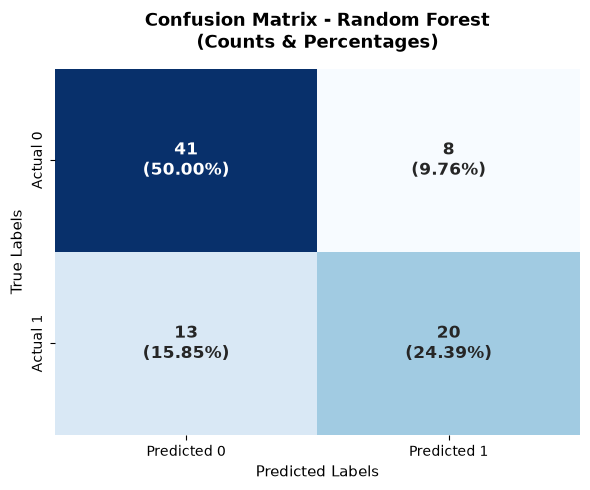


     FINAL HOLDOUT TEST PERFORMANCE       
Accuracy  : 0.7439
Precision : 0.7143
Recall    : 0.6061
F1-Score  : 0.6557


In [142]:
# Evaluate Best Random Forest
rf_test_preds = rf_grid.best_estimator_.predict(X_test)
print("\n" + "="*40 + "\n  RANDOM FOREST HOLDOUT TEST REPORT\n" + "="*40)
print(classification_report(y_test, rf_test_preds))
plot_confusion_matrix(y_test, rf_test_preds, "Random Forest")

print("\n==========================================")
print("     FINAL HOLDOUT TEST PERFORMANCE       ")
print("==========================================")
print(f"Accuracy  : {accuracy_score(y_test, rf_test_preds):.4f}")
print(f"Precision : {precision_score(y_test, rf_test_preds):.4f}")
print(f"Recall    : {recall_score(y_test, rf_test_preds):.4f}")
print(f"F1-Score  : {f1_score(y_test, rf_test_preds):.4f}")


  LIGHTGBM HOLDOUT TEST REPORT
              precision    recall  f1-score   support

           0       0.79      0.84      0.81        49
           1       0.73      0.67      0.70        33

    accuracy                           0.77        82
   macro avg       0.76      0.75      0.76        82
weighted avg       0.77      0.77      0.77        82



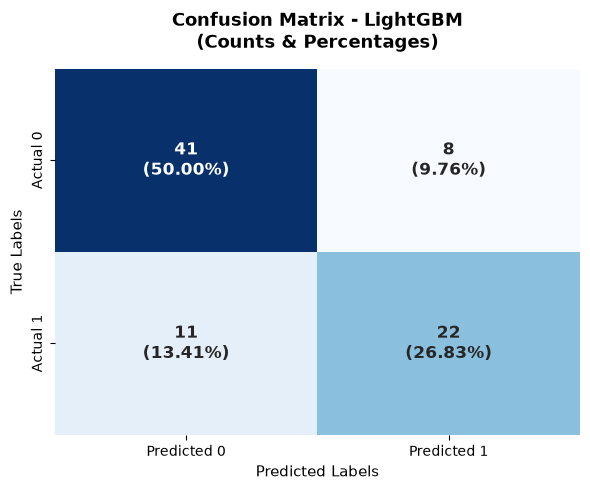


     FINAL HOLDOUT TEST PERFORMANCE       
Accuracy  : 0.7683
Precision : 0.7333
Recall    : 0.6667
F1-Score  : 0.6984


In [143]:
best_lgbm = lgbm_grid.best_estimator_
test_preds = best_lgbm.predict(X_test) # type: ignore

print("\n" + "="*40 + "\n  LIGHTGBM HOLDOUT TEST REPORT\n" + "="*40)
print(classification_report(y_test, test_preds))
plot_confusion_matrix(y_test, test_preds, "LightGBM")

print("\n==========================================")
print("     FINAL HOLDOUT TEST PERFORMANCE       ")
print("==========================================")
print(f"Accuracy  : {accuracy_score(y_test, test_preds):.4f}")
print(f"Precision : {precision_score(y_test, test_preds):.4f}")
print(f"Recall    : {recall_score(y_test, test_preds):.4f}")
print(f"F1-Score  : {f1_score(y_test, test_preds):.4f}")


  XGBOOST HOLDOUT TEST REPORT
              precision    recall  f1-score   support

           0       0.82      0.84      0.83        49
           1       0.75      0.73      0.74        33

    accuracy                           0.79        82
   macro avg       0.78      0.78      0.78        82
weighted avg       0.79      0.79      0.79        82



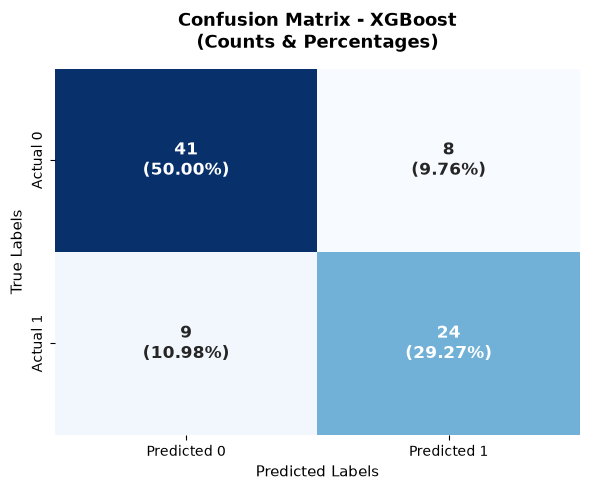


     FINAL HOLDOUT TEST PERFORMANCE       
Accuracy  : 0.7927
Precision : 0.7500
Recall    : 0.7273
F1-Score  : 0.7385


In [144]:
best_xgb = xgb_grid.best_estimator_
test_preds = best_xgb.predict(X_test) # type: ignore

print("\n" + "="*40 + "\n  XGBOOST HOLDOUT TEST REPORT\n" + "="*40)
print(classification_report(y_test, test_preds))
plot_confusion_matrix(y_test, test_preds, "XGBoost")

print("\n==========================================")
print("     FINAL HOLDOUT TEST PERFORMANCE       ")
print("==========================================")
print(f"Accuracy  : {accuracy_score(y_test, test_preds):.4f}")
print(f"Precision : {precision_score(y_test, test_preds):.4f}")
print(f"Recall    : {recall_score(y_test, test_preds):.4f}")
print(f"F1-Score  : {f1_score(y_test, test_preds):.4f}")

# OSC

In [145]:
# 1. Run the preprocessing function
output = preprocess_dataframe(osc)
X_osc = output[0]
y_osc = output[1]
laser_encoder_osc = output[2] if len(output) > 2 else None

In [146]:
print(X_osc.shape)

(307, 200)


In [147]:
# 2. Fit and transform using your generic filter
feature_filter = VarianceCorrelationFilter(var_threshold=1e-6, corr_threshold=0.95)
X_filtered_osc = feature_filter.fit_transform(X_osc)

# 3. Visualise the correlations if desired
feature_filter.visualize_correlations()
X_filtered_osc.shape


=== TOP 20 HIGHEST CORRELATIONS ===
Current Filter Threshold: 0.95

              Feature 1             Feature 2 Correlation                     Action
0       BP_sym_vertical         BP_sym_diag_2      1.0000         Drop BP_sym_diag_2
1       BD_sym_vertical         BD_sym_diag_2      1.0000         Drop BD_sym_diag_2
2    BP_marginal_skew_x  BP_moment_skewness_x      1.0000  Drop BP_moment_skewness_x
3    BD_marginal_skew_y  BD_moment_skewness_y      1.0000  Drop BD_moment_skewness_y
4    BD_marginal_skew_x  BD_moment_skewness_x      1.0000  Drop BD_moment_skewness_x
5    BP_marginal_skew_y  BP_moment_skewness_y      1.0000  Drop BP_moment_skewness_y
6   BP_iso_rotation_deg  cross_rotation_delta      1.0000  Drop cross_rotation_delta
7      BD_zone_0_3_mean       BD_zone_0_3_p90      1.0000       Drop BD_zone_0_3_p90
8    BD_iso_ellipticity   BD_iso_eccentricity      0.9999   Drop BD_iso_eccentricity
9         BD_global_p10       BD_zone_1_1_p90      0.9998       Drop BD_zone_1_1_

(307, 110)

In [148]:
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered_osc, y_osc, test_size=0.30, random_state=42, stratify=y_osc
)

In [149]:
# 1. Random Forest
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=cv_strategy, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)
evaluate_cross_validation("Random Forest", rf_grid, X_train, y_train)


      CROSS-VALIDATION RESULTS: Random Forest       
Fold 1 -> Accuracy: 0.9535 | Precision: 0.8750 | Recall: 1.0000 | F1: 0.9333
Fold 2 -> Accuracy: 0.9302 | Precision: 0.8667 | Recall: 0.9286 | F1: 0.8966
Fold 3 -> Accuracy: 0.8837 | Precision: 0.7647 | Recall: 0.9286 | F1: 0.8387
Fold 4 -> Accuracy: 0.7907 | Precision: 0.6667 | Recall: 0.7143 | F1: 0.6897
Fold 5 -> Accuracy: 0.7857 | Precision: 0.6667 | Recall: 0.6154 | F1: 0.6400

---> Best Model Parameters:
     * class_weight: balanced
     * max_depth: 10
     * min_samples_split: 5
     * n_estimators: 200


In [150]:
# 2. LightGBM
# verbosity=-1 turns off background optimization logs
lgbm_grid = GridSearchCV(
    LGBMClassifier(random_state=42, verbosity=-1), # type: ignore
    param_grid=lgbm_param_grid, 
    cv=cv_strategy, 
    scoring='f1_macro', 
    n_jobs=-1
)
lgbm_grid.fit(X_train, y_train)
evaluate_cross_validation("LightGBM", lgbm_grid, X_train, y_train)


      CROSS-VALIDATION RESULTS: LightGBM       
Fold 1 -> Accuracy: 0.9302 | Precision: 0.8667 | Recall: 0.9286 | F1: 0.8966
Fold 2 -> Accuracy: 0.9070 | Precision: 0.8571 | Recall: 0.8571 | F1: 0.8571
Fold 3 -> Accuracy: 0.9070 | Precision: 0.8125 | Recall: 0.9286 | F1: 0.8667
Fold 4 -> Accuracy: 0.7442 | Precision: 0.6000 | Recall: 0.6429 | F1: 0.6207
Fold 5 -> Accuracy: 0.8095 | Precision: 0.6923 | Recall: 0.6923 | F1: 0.6923

---> Best Model Parameters:
     * is_unbalance: True
     * learning_rate: 0.01
     * max_depth: 5
     * n_estimators: 200


In [151]:
from typing import cast

xgb_model = XGBClassifier(
    random_state=42, 
    eval_metric='logloss'
)

xgb_grid = GridSearchCV(
    estimator=cast(BaseEstimator, xgb_model),
    param_grid=xgb_param_grid,
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)
evaluate_cross_validation("XGBoost", xgb_grid, X_train, y_train)


      CROSS-VALIDATION RESULTS: XGBoost       
Fold 1 -> Accuracy: 0.9535 | Precision: 0.8750 | Recall: 1.0000 | F1: 0.9333
Fold 2 -> Accuracy: 0.9070 | Precision: 0.9167 | Recall: 0.7857 | F1: 0.8462
Fold 3 -> Accuracy: 0.9070 | Precision: 0.8125 | Recall: 0.9286 | F1: 0.8667
Fold 4 -> Accuracy: 0.8140 | Precision: 0.7143 | Recall: 0.7143 | F1: 0.7143
Fold 5 -> Accuracy: 0.8095 | Precision: 0.8571 | Recall: 0.4615 | F1: 0.6000

---> Best Model Parameters:
     * colsample_bytree: 0.6
     * learning_rate: 0.05
     * max_depth: 4
     * min_child_weight: 5
     * n_estimators: 200
     * reg_alpha: 1
     * reg_lambda: 1
     * subsample: 0.9



  RANDOM FOREST HOLDOUT TEST REPORT
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        63
           1       0.74      0.77      0.75        30

    accuracy                           0.84        93
   macro avg       0.81      0.82      0.82        93
weighted avg       0.84      0.84      0.84        93



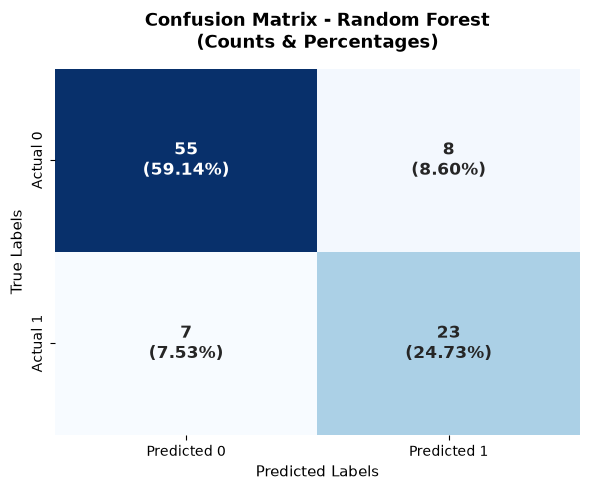


     FINAL HOLDOUT TEST PERFORMANCE       
Accuracy  : 0.8387
Precision : 0.7419
Recall    : 0.7667
F1-Score  : 0.7541


In [152]:
# Evaluate Best Random Forest
rf_test_preds = rf_grid.best_estimator_.predict(X_test)
print("\n" + "="*40 + "\n  RANDOM FOREST HOLDOUT TEST REPORT\n" + "="*40)
print(classification_report(y_test, rf_test_preds))
plot_confusion_matrix(y_test, rf_test_preds, "Random Forest")

print("\n==========================================")
print("     FINAL HOLDOUT TEST PERFORMANCE       ")
print("==========================================")
print(f"Accuracy  : {accuracy_score(y_test, rf_test_preds):.4f}")
print(f"Precision : {precision_score(y_test, rf_test_preds):.4f}")
print(f"Recall    : {recall_score(y_test, rf_test_preds):.4f}")
print(f"F1-Score  : {f1_score(y_test, rf_test_preds):.4f}")


  LIGHTGBM HOLDOUT TEST REPORT
              precision    recall  f1-score   support

           0       0.90      0.87      0.89        63
           1       0.75      0.80      0.77        30

    accuracy                           0.85        93
   macro avg       0.83      0.84      0.83        93
weighted avg       0.85      0.85      0.85        93



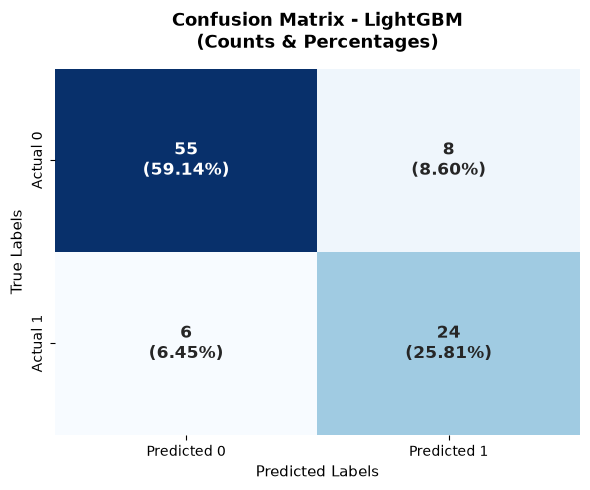


     FINAL HOLDOUT TEST PERFORMANCE       
Accuracy  : 0.8495
Precision : 0.7500
Recall    : 0.8000
F1-Score  : 0.7742


In [153]:
best_lgbm = lgbm_grid.best_estimator_
test_preds = best_lgbm.predict(X_test) # type: ignore

print("\n" + "="*40 + "\n  LIGHTGBM HOLDOUT TEST REPORT\n" + "="*40)
print(classification_report(y_test, test_preds))
plot_confusion_matrix(y_test, test_preds, "LightGBM")

print("\n==========================================")
print("     FINAL HOLDOUT TEST PERFORMANCE       ")
print("==========================================")
print(f"Accuracy  : {accuracy_score(y_test, test_preds):.4f}")
print(f"Precision : {precision_score(y_test, test_preds):.4f}")
print(f"Recall    : {recall_score(y_test, test_preds):.4f}")
print(f"F1-Score  : {f1_score(y_test, test_preds):.4f}")


  XGBOOST HOLDOUT TEST REPORT
              precision    recall  f1-score   support

           0       0.87      0.92      0.89        63
           1       0.81      0.70      0.75        30

    accuracy                           0.85        93
   macro avg       0.84      0.81      0.82        93
weighted avg       0.85      0.85      0.85        93



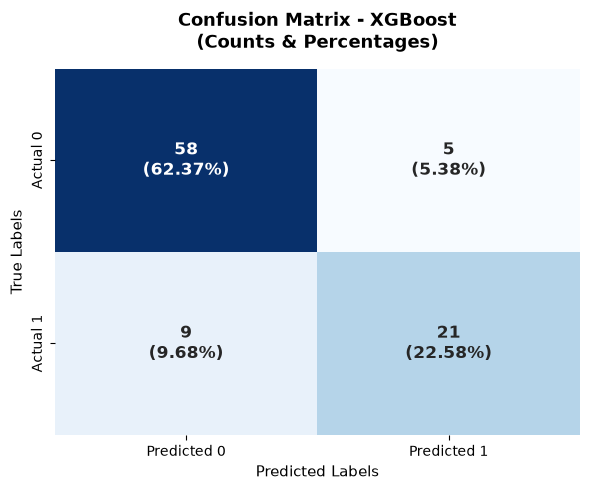


     FINAL HOLDOUT TEST PERFORMANCE       
Accuracy  : 0.8495
Precision : 0.8077
Recall    : 0.7000
F1-Score  : 0.7500


In [154]:
best_xgb = xgb_grid.best_estimator_
test_preds = best_xgb.predict(X_test) # type: ignore

print("\n" + "="*40 + "\n  XGBOOST HOLDOUT TEST REPORT\n" + "="*40)
print(classification_report(y_test, test_preds))
plot_confusion_matrix(y_test, test_preds, "XGBoost")

print("\n==========================================")
print("     FINAL HOLDOUT TEST PERFORMANCE       ")
print("==========================================")
print(f"Accuracy  : {accuracy_score(y_test, test_preds):.4f}")
print(f"Precision : {precision_score(y_test, test_preds):.4f}")
print(f"Recall    : {recall_score(y_test, test_preds):.4f}")
print(f"F1-Score  : {f1_score(y_test, test_preds):.4f}")